# Stage 2 ProxyOpt - SP Eval Analyzer & Visualizer

In [1]:
import numpy as np
import shutil
import os
from pathlib import Path
import pandas as pd
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import cv2
import warnings

pd.set_option('display.max_rows', 500)
%cd /home/boat/proxyISP/pytorch-superpoint

/home/boat/proxyISP/pytorch-superpoint


/home/boat/miniconda3/envs/proxyopt/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


### Specify Evaluation Directories

In [2]:
eval_log_dirs = [
    "logs/eval_sl_v16.1_original",
    "logs/eval_sl_train_v16.1_sunlit_lr0.0005_5000",
    "logs/eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000"
]

In [3]:
objects = {}
for d in eval_log_dirs:
    objects[os.path.basename(d)] = (np.load(Path(d) / "predictions" / "result.npz"))
objects

{'eval_sl_v16.1_original': NpzFile 'logs/eval_sl_v16.1_original/predictions/result.npz' with keys: repeatability, localization_err, correctness, homography_thresh, mscore...,
 'eval_sl_train_v16.1_sunlit_lr0.0005_5000': NpzFile 'logs/eval_sl_train_v16.1_sunlit_lr0.0005_5000/predictions/result.npz' with keys: repeatability, localization_err, correctness, homography_thresh, mscore...,
 'eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000': NpzFile 'logs/eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000/predictions/result.npz' with keys: repeatability, localization_err, correctness, homography_thresh, mscore...}

### Single Value Metrics

In [4]:
for k in ["repeatability", "localization_err", "mscore", "mAP"]:
    print(f"{k}:")
    df = pd.DataFrame()
    for key, object in objects.items():
        value = object[k].mean(axis = 0)
        df[key] = np.array([value])
    display(df)

repeatability:


,eval_sl_v16.1_original,eval_sl_train_v16.1_sunlit_lr0.0005_5000,eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000
0,0.58654,0.588485,0.582647


localization_err:


,eval_sl_v16.1_original,eval_sl_train_v16.1_sunlit_lr0.0005_5000,eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000
0,1.15366,1.151302,1.142235


mscore:


,eval_sl_v16.1_original,eval_sl_train_v16.1_sunlit_lr0.0005_5000,eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000
0,0.244397,0.242199,0.237074


mAP:


,eval_sl_v16.1_original,eval_sl_train_v16.1_sunlit_lr0.0005_5000,eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000
0,0.650418,0.651772,0.637294


### Homography Correctness @k

In [8]:
def show_homography_correctness(obj, only_diff = False, row_id_to_filter = None, plot_image = False, plot= "matching", single_table = False):
    first_name = next(iter(obj))
    thresh = obj[first_name]["homography_thresh"]
    longest_name_len = max([len(name) for name in obj])
    
    if single_table:
        df = pd.DataFrame()
        df_accum = pd.DataFrame()
        totals = []
        for k,t in enumerate(thresh):
            total = []
            for eval_id, (name, v) in enumerate(obj.items()):
                correctness_at_k = v["correctness"][:, k]
                total.append(correctness_at_k)
                # print("\t" + name," " * (longest_name_len - len(name)), "mean", correctness_at_k.mean(), " | sum", correctness_at_k.sum())
            # total = np.stack(total)
            totals.append(total)
        # Thresh,Eval,NumPair -> Numpairs, Eval, 1 (string of T, F of each threash)
        totals = np.stack(totals)
        totals = np.swapaxes(totals, 2, 0)
        totals = totals.tolist()
        TFs = []
        for p in totals:
            totals_ = []
            for ev in p:
                str_ = ""
                for t in ev:
                    str_ += ("T" if t else "F") + " "
                totals_.append(str_)
            TFs.append(totals_)
        # print(TFs)
        for k, tf in enumerate(TFs):
            for eval_id, (name, v) in enumerate(obj.items()):
                df.at[k, name] = tf[eval_id]
                # df_accum.at[k, "accum @k"]
        display(df)
            # df["is_diff"] = (total.sum(axis = 0) < total.shape[0]) & (total.sum(axis = 0) > 0)
         
    for k,t in enumerate(thresh):
        print(f"homography correctness @{t}\n mean:")
        df = pd.DataFrame()
        total = []
        for eval_id, (name, v) in enumerate(obj.items()):
            correctness_at_k = v["correctness"][:, k]
            df[f" [{eval_id}] {name[-15:]}"] = correctness_at_k
            total.append(correctness_at_k)
            print("\t" + name," " * (longest_name_len - len(name)), "mean", correctness_at_k.mean(), " | sum", correctness_at_k.sum())
        total = np.stack(total)
        df["is_diff"] = (total.sum(axis = 0) < total.shape[0]) & (total.sum(axis = 0) > 0)
        if row_id_to_filter is not None:
            df = df.loc[row_id_to_filter]
        if only_diff:
            df = df[df["is_diff"] == True]
        print()
        if not single_table:
            display(df)

    if plot_image and row_id_to_filter is None:
        warnings.warn("Image will not be plotted, row_id_to_filter is None, plotting all images will slow down the notebook")
    if plot_image and row_id_to_filter is not None:
        for index, row in df.iterrows():
            print(f"pair {index}")
            for d in eval_log_dirs:
                base_path = Path(d) / "predictions"
                if plot == "matching":
                    image_filepath = base_path / "matching" / f"{index}m.png"
                if plot == "warping":
                    image_filepath = base_path / "warping" / f"{index}.png"
                image_image = cv2.imread(str(image_filepath))
                plt.imshow(image_image[:,:,::-1])
                plt.xlabel(f"\t{os.path.basename(d)}")
                plt.show()
            print("")

only_diff = False
# row_id_to_filter =  [7]
row_id_to_filter = None
plot_image = False
single_table = True
plot = "matching"

show_homography_correctness(objects, only_diff = only_diff, row_id_to_filter = row_id_to_filter, plot_image = plot_image, plot=plot, single_table=single_table)

,eval_sl_v16.1_original,eval_sl_train_v16.1_sunlit_lr0.0005_5000,eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000
0,F T T T T T,F T T T T T,F T T T T T
1,F F T T T T,F T T T T T,F F F T T T
2,F T T T T T,F F T T T T,F T T T T T
3,F T T T T T,F T T T T T,F T T T T T
4,F F F T T T,F T T T T T,F T T T T T
5,T T T T T T,T T T T T T,T T T T T T
6,F F F F F T,F F F F F T,F F F F T T
7,T T T T T T,F T T T T T,T T T T T T
8,F F F T T T,F F F F T T,F F T T T T
9,F F F F F T,F F F F F F,F F F F F F


homography correctness @1
 mean:
	eval_sl_v16.1_original                             mean 0.14444444444444443  | sum 13
	eval_sl_train_v16.1_sunlit_lr0.0005_5000           mean 0.15555555555555556  | sum 14
	eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000  mean 0.16666666666666666  | sum 15

homography correctness @3
 mean:
	eval_sl_v16.1_original                             mean 0.4222222222222222  | sum 38
	eval_sl_train_v16.1_sunlit_lr0.0005_5000           mean 0.5111111111111111  | sum 46
	eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000  mean 0.4444444444444444  | sum 40

homography correctness @5
 mean:
	eval_sl_v16.1_original                             mean 0.5777777777777777  | sum 52
	eval_sl_train_v16.1_sunlit_lr0.0005_5000           mean 0.6  | sum 54
	eval_sl_train_v16.1_sunlit_lr0.0005_gradac8_40000  mean 0.5555555555555556  | sum 50

homography correctness @10
 mean:
	eval_sl_v16.1_original                             mean 0.7  | sum 63
	eval_sl_train_v16.1_sunlit_lr0

# Optimized Hype Visualize

In [62]:
# plot_original_hype = True
# limit = 10
# config_path = "../ProxyOpt/train_configs/v16.1.yaml"
# images_path = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/low-light"
# hype_checkpoint_paths = [
#     "logs_backup/train_v16.1_lowlight_lr0.0005_gradac8/proxyopt_checkpoints/checkpoint_40000.pkl"
# ]

plot_original_hype = True
limit = 10
config_path = "../ProxyOpt/train_configs/v16.1.yaml"
images_path = "/mnt/ssd2tb/boat/thesis/s21fe_dataset/raw/sunlit"
hype_checkpoint_paths = [
    "logs/train_v16.1_sunlit_lr0.0005_gradac8/proxyopt_checkpoints/checkpoint_40000.pkl"
]

[04-30 18:39:00] ProxyISPDataset.py INFO - Initializing ProxyISPDataset Dataset...
[04-30 18:39:00] ProxyISPDataset.py INFO - total raw images: 188


/home/boat/proxyISP/pytorch-superpoint


[04-30 18:39:01] ProxyISPDataset.py INFO - hyperp length: 20000
[04-30 18:39:01] ProxyISPDataset.py INFO - num_hyperp x num_image: 3760000
[04-30 18:39:01] ProxyISPDataset.py INFO - total dataset length: 3760000


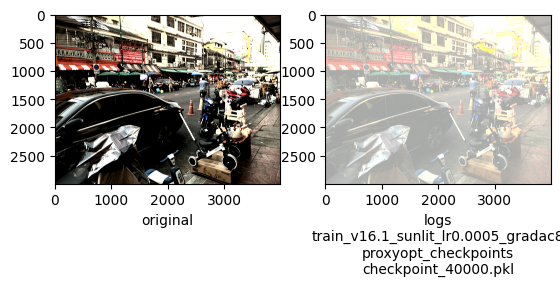

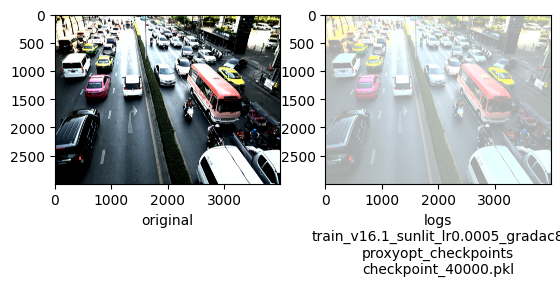

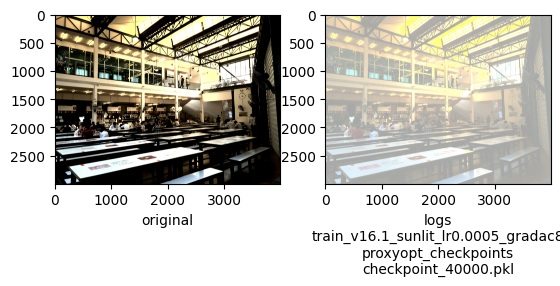

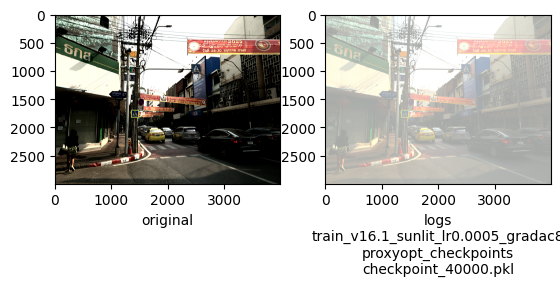

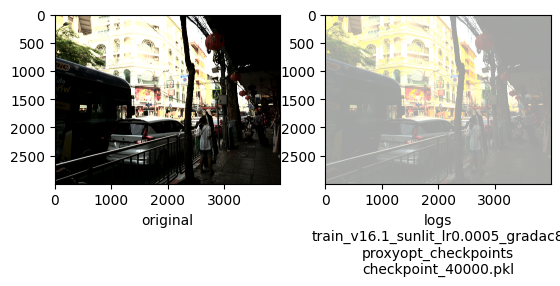

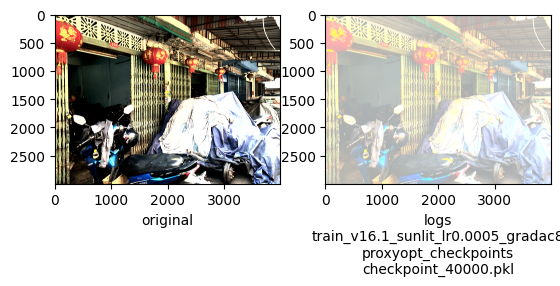

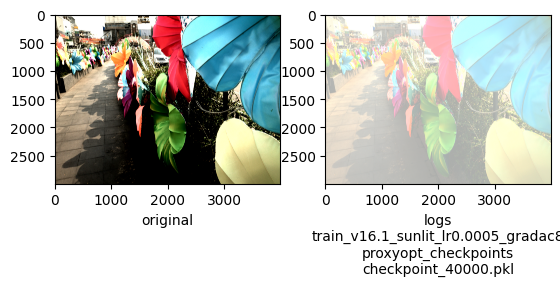

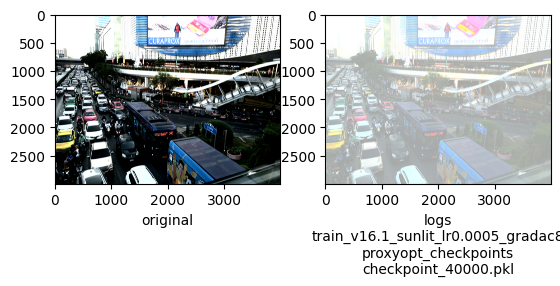

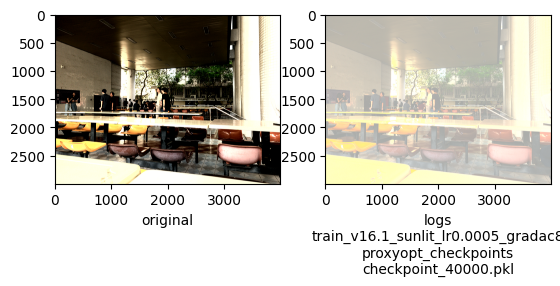

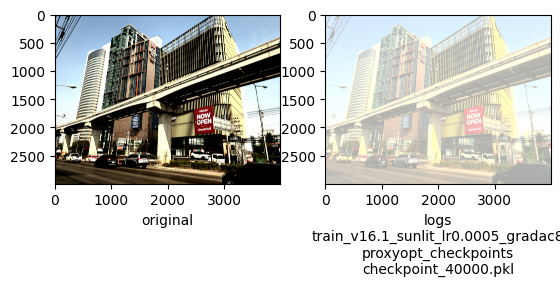

In [63]:
%cd /home/boat/proxyISP/pytorch-superpoint

import sys
sys.path.insert(0, "../ProxyOpt/")
sys.path.insert(0, "../fast-openISP/")
import yaml
import rawpy
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import io

from ISP_tools.ProxyISPDataset import ProxyISPDataset, EXPERIMENT_OUTPUT_PATH

isp_hyps = [np.load(p, allow_pickle = True)['proxy_hype'] for p in hype_checkpoint_paths]

with open(config_path, "r") as f:
    yaml_dict = yaml.safe_load(f)

config = yaml_dict["config"]
openisp_config = yaml_dict["openisp_config"]
hyp_setting = yaml_dict["hyp_setting"]

additional_conf = {
        # "target_image": ["/home/boat/proxyISP/data/s21fe_dataset/20240115_123915.dng"],
        # "target_image": ["/home/boat/proxyISP/data/s21fe_dataset/20240117_182706.dng"],
        "proxyopt_base_path": "/home/boat/proxyISP/ProxyOpt/"
}

raw_images = [str(p) for p in Path(images_path).rglob("*.dng")]
additional_conf["target_image"] = raw_images

dataset = ProxyISPDataset(config, openisp_config, hyp_setting, additional_conf)

total_figure_per_image = len(isp_hyps) + plot_original_hype
with redirect_stdout(io.StringIO()):
    for image_path in dataset.raw_img[:10]:
        print("image : ", os.path.basename(image_path))
        bayer = rawpy.imread(image_path).raw_image
        if plot_original_hype:
            plt.subplot(1, total_figure_per_image, 1)
            processed = dataset.process_raw(bayer, original_hyp = True)
            plt.imshow(processed)
            plt.xlabel("original")
        for k, isp_hyp in enumerate(isp_hyps):
            isp_hyp = dataset.denormalize_hyp(isp_hyp)
            processed = dataset.process_raw(bayer, isp_hyp,original_hyp = False)
            plt.subplot(1, total_figure_per_image, k + total_figure_per_image)
            plt.imshow(processed)
            plt.xlabel(hype_checkpoint_paths[k].replace("/", "\n"))
        plt.show()

In [44]:
isp_hyp

array([0.9604979 , 0.01150501, 0.35200042, 0.00300499, 0.5559965 ,
       0.8419903 , 0.08050434, 0.00100497, 0.00650494, 0.2885065 ,
       0.00750141, 0.6327546 , 0.52334064], dtype=float32)